In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(der_K.shape[0], 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        return 0.5 * jnp.sum(self.K * del_strain**2) + self.mlp(del_strain)
        # return self.mlp(del_strain)



In [2]:

validate_model(Example)
final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output.npz", valid_file="output_valid.npz", n_epochs=500, lr=1e-2)

train.qs shape:  (11, 11)
valid.qs shape:  (11, 11)
Step 0    | Train: 2.70084e-04  | Valid: 2.00609e-05 
Step 10   | Train: 2.46134e-04  | Valid: 1.15232e-05 
Step 20   | Train: 2.50198e-04  | Valid: 2.71026e-05 
Step 30   | Train: 2.46481e-04  | Valid: 2.88683e-05 
Step 40   | Train: 2.44845e-04  | Valid: 1.74167e-05 
Step 50   | Train: 2.43622e-04  | Valid: 1.83179e-05 
Step 60   | Train: 2.46162e-04  | Valid: 1.85074e-05 
Step 70   | Train: 2.50616e-04  | Valid: 2.40370e-05 
Step 80   | Train: 2.54792e-04  | Valid: 2.70420e-05 
Step 90   | Train: 2.58854e-04  | Valid: 2.97937e-05 
Step 100  | Train: 2.64208e-04  | Valid: 3.33768e-05 
Step 110  | Train: 2.71689e-04  | Valid: 3.78851e-05 
Step 120  | Train: 2.75349e-04  | Valid: 3.64951e-05 
Step 130  | Train: 2.46026e-04  | Valid: 4.88543e-06 
Step 140  | Train: 2.49221e-04  | Valid: 1.03240e-05 
Step 150  | Train: 2.48030e-04  | Valid: 1.36094e-05 
Step 160  | Train: 2.46509e-04  | Valid: 1.31705e-05 
Step 170  | Train: 2.45530e-04

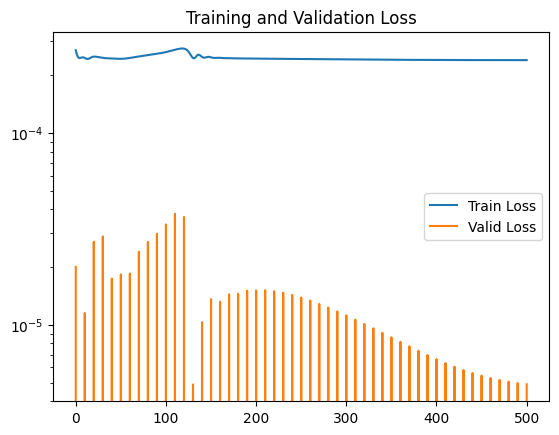

In [3]:
import matplotlib.pyplot as plt
plt.plot(train_history, label="Train Loss")
plt.plot(valid_history, label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [4]:
from util import TestCase

train = TestCase.from_npz("output.npz")
valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[0])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.    0.    0.    0.    0.   -0.1   0.    0.05]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.    0.    0.    0.    0.   -0.1   0.   -0.05]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [5]:

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [6]:
animate(valid.qs)

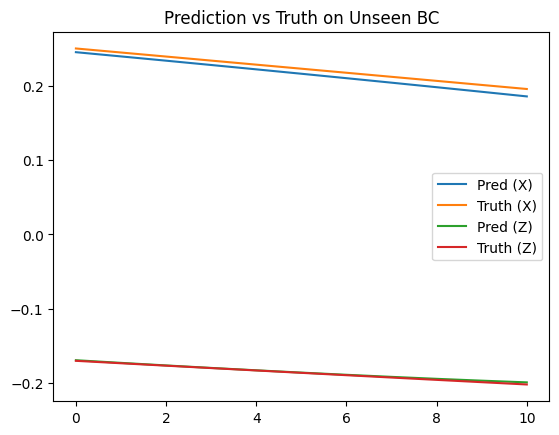

In [7]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.show()

In [8]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.5 0.  0. ]
final:  [0.4  0.   0.05]
Validation BC:
init:  [0.5 0.  0. ]
final:  [ 0.4   0.   -0.05]


In [9]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the training data:  [ 2.04503756e-01 -5.49553991e-05 -1.51743630e-01]


In [10]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the validation data:  [ 1.95521151e-01  6.64904575e-05 -2.01744441e-01]


In [11]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [ 2.45012546e-01 -8.37586188e-12 -1.69123223e-01]
final position of the middle node in the prediction:  [ 1.85553292e-01  9.05176569e-13 -1.98914315e-01]
